In [48]:
import matplotlib
import pickle
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sb
from scipy import stats
from scipy.stats import binom
import datetime
import statistics
import multiprocess as mp
import time
import arviz as az

from epydemix import EpiModel
from epydemix import load_predefined_model
from epydemix.visualization import plot_quantiles, plot_trajectories, plot_posterior_distribution_2d
from epydemix.population import load_epydemix_population, Population, get_available_locations
from epydemix.visualization import plot_contact_matrix, plot_population
from epydemix.utils import compute_simulation_dates
from epydemix import simulate
from epydemix.calibration import ABCSampler, rmse
import matplotlib.pyplot as plt
import pandas as pd
from epydemix.visualization import plot_posterior_distribution

from Epy_functions import stochastic_sir
from Epy_functions import stochastic_sir_noisy
from Epy_functions import summary

# Simulation

In [49]:
N = 10000
I0 = 10

In [50]:
# Simulate an epidemic with full observations (incidence data) 
model = stochastic_sir_noisy(0.45, 0.08, N, I0, 100, 0.25, 5)

In [51]:
# Isolate the observations
incidence_observed = (model['incidence'])

# Create DataFrame of observations (this is what Epydemix accepts)
incidence_df = pd.DataFrame(incidence_observed)
incidence_df = incidence_df.rename(columns={0: 'data'})
incidence_df['date'] = pd.date_range(start = '2024/01/01', periods = len(incidence_df), freq='D')

In [52]:
# Priors
priors = {"beta": stats.gamma(4.5, scale = 0.1), 
          "gamma": stats.gamma(8, scale = .01)}

# Simulation parameters
parameters = {'N': N,
              'n_i': I0,
              'timesteps': 100,
              'rho': .25,
              'phi': 1}

# Wrapper function
def simulate_wrapper(parameters):
    results = stochastic_sir_noisy(**parameters)
    return{'data': results['incidence']}

# Initialize the ABCSampler object
abc_sampler = ABCSampler(simulation_function=simulate_wrapper,
                         priors = priors,
                         parameters=parameters,
                         observed_data=incidence_observed,
                         distance_function = rmse)

# Number of Particles

## Calibration

In [53]:
def smc_calibrate(seed, particles):
    np.random.seed(seed)
    results_smc = abc_sampler.calibrate(strategy='smc',
                                    num_particles=particles,
                                    num_generations=10,
                                    )
    return results_smc

In [54]:
results_250 = smc_calibrate(1, 250)

Starting ABC-SMC with 250 particles and 10 generations

Generation 1/10 (epsilon: inf)
	Accepted 250/250 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/10 (epsilon: 216.570915)
	Accepted 250/876 (acceptance rate: 28.54%)
	Elapsed time: 00:00:00

Generation 3/10 (epsilon: 129.055085)
	Accepted 250/1599 (acceptance rate: 15.63%)
	Elapsed time: 00:00:00

Generation 4/10 (epsilon: 64.613389)
	Accepted 250/2489 (acceptance rate: 10.04%)
	Elapsed time: 00:00:00

Generation 5/10 (epsilon: 38.664194)
	Accepted 250/3988 (acceptance rate: 6.27%)
	Elapsed time: 00:00:00

Generation 6/10 (epsilon: 24.218588)
	Accepted 250/7113 (acceptance rate: 3.51%)
	Elapsed time: 00:00:00

Generation 7/10 (epsilon: 18.286743)
	Accepted 250/12290 (acceptance rate: 2.03%)
	Elapsed time: 00:00:01

Generation 8/10 (epsilon: 15.157171)
	Accepted 250/20463 (acceptance rate: 1.22%)
	Elapsed time: 00:00:01

Generation 9/10 (epsilon: 13.113733)
	Accepted 250/33962 (acceptance rate: 0.74%)
	Elapsed time

In [55]:
results_500 = smc_calibrate(1, 500)

Starting ABC-SMC with 500 particles and 10 generations

Generation 1/10 (epsilon: inf)
	Accepted 500/500 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/10 (epsilon: 202.049467)
	Accepted 500/2148 (acceptance rate: 23.28%)
	Elapsed time: 00:00:00

Generation 3/10 (epsilon: 118.574650)
	Accepted 500/3533 (acceptance rate: 14.15%)
	Elapsed time: 00:00:00

Generation 4/10 (epsilon: 56.729575)
	Accepted 500/5703 (acceptance rate: 8.77%)
	Elapsed time: 00:00:01

Generation 5/10 (epsilon: 32.659815)
	Accepted 500/9800 (acceptance rate: 5.10%)
	Elapsed time: 00:00:01

Generation 6/10 (epsilon: 22.045814)
	Accepted 500/17366 (acceptance rate: 2.88%)
	Elapsed time: 00:00:02

Generation 7/10 (epsilon: 17.465394)
	Accepted 500/28266 (acceptance rate: 1.77%)
	Elapsed time: 00:00:03

Generation 8/10 (epsilon: 14.282856)
	Accepted 500/49943 (acceptance rate: 1.00%)
	Elapsed time: 00:00:05

Generation 9/10 (epsilon: 12.625766)
	Accepted 500/87820 (acceptance rate: 0.57%)
	Elapsed tim

In [56]:
results_750 = smc_calibrate(1, 750)

Starting ABC-SMC with 750 particles and 10 generations

Generation 1/10 (epsilon: inf)
	Accepted 750/750 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/10 (epsilon: 196.602618)
	Accepted 750/2957 (acceptance rate: 25.36%)
	Elapsed time: 00:00:01

Generation 3/10 (epsilon: 108.642754)
	Accepted 750/5240 (acceptance rate: 14.31%)
	Elapsed time: 00:00:01

Generation 4/10 (epsilon: 55.131113)
	Accepted 750/8580 (acceptance rate: 8.74%)
	Elapsed time: 00:00:01

Generation 5/10 (epsilon: 32.665489)
	Accepted 750/14186 (acceptance rate: 5.29%)
	Elapsed time: 00:00:02

Generation 6/10 (epsilon: 23.419433)
	Accepted 750/24229 (acceptance rate: 3.10%)
	Elapsed time: 00:00:03

Generation 7/10 (epsilon: 18.099005)
	Accepted 750/40335 (acceptance rate: 1.86%)
	Elapsed time: 00:00:04

Generation 8/10 (epsilon: 14.760420)
	Accepted 750/69040 (acceptance rate: 1.09%)
	Elapsed time: 00:00:07

Generation 9/10 (epsilon: 12.915493)
	Accepted 750/116904 (acceptance rate: 0.64%)
	Elapsed t

In [57]:
results_1000 = smc_calibrate(1, 1000)

Starting ABC-SMC with 1000 particles and 10 generations

Generation 1/10 (epsilon: inf)
	Accepted 1000/1000 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/10 (epsilon: 201.371849)
	Accepted 1000/3900 (acceptance rate: 25.64%)
	Elapsed time: 00:00:02

Generation 3/10 (epsilon: 117.938528)
	Accepted 1000/6774 (acceptance rate: 14.76%)
	Elapsed time: 00:00:02

Generation 4/10 (epsilon: 62.269294)
	Accepted 1000/10566 (acceptance rate: 9.46%)
	Elapsed time: 00:00:02

Generation 5/10 (epsilon: 36.828657)
	Accepted 1000/17120 (acceptance rate: 5.84%)
	Elapsed time: 00:00:03

Generation 6/10 (epsilon: 24.712546)
	Accepted 1000/28310 (acceptance rate: 3.53%)
	Elapsed time: 00:00:04

Generation 7/10 (epsilon: 18.752865)
	Accepted 1000/48445 (acceptance rate: 2.06%)
	Elapsed time: 00:00:06

Generation 8/10 (epsilon: 15.306207)
	Accepted 1000/80668 (acceptance rate: 1.24%)
	Elapsed time: 00:00:09

Generation 9/10 (epsilon: 13.166055)
	Accepted 1000/145510 (acceptance rate: 0.69%

## Posterior Analysis

In [58]:
posterior_250 = results_250.get_posterior_distribution()
posterior_500 = results_500.get_posterior_distribution()
posterior_750 = results_750.get_posterior_distribution()
posterior_1000 = results_1000.get_posterior_distribution()

In [59]:
beta_mean_250 = np.mean(posterior_250['beta'])
beta_mean_500 = np.mean(posterior_500['beta'])
beta_mean_750 = np.mean(posterior_750['beta'])
beta_mean_1000 = np.mean(posterior_1000['beta'])

gamma_mean_250 = np.mean(posterior_250['gamma'])
gamma_mean_500 = np.mean(posterior_500['gamma'])
gamma_mean_750 = np.mean(posterior_750['gamma'])
gamma_mean_1000 = np.mean(posterior_1000['gamma'])


beta_true=0.45
summary_beta = {'Number of Particles': ['250', '500', '750', '1000'],
           'Mean': [beta_mean_250, beta_mean_500, beta_mean_750, beta_mean_1000],
           'Bias': [(beta_mean_250 - beta_true), (beta_mean_500 - beta_true), (beta_mean_750 - beta_true), (beta_mean_1000 - beta_true)]}

gamma_true=0.08
summary_gamma = {'Number of Particles': ['250', '500', '750', '1000'],
           'Mean': [gamma_mean_250, gamma_mean_500, gamma_mean_750, gamma_mean_1000],
           'Bias': [(gamma_mean_250 - gamma_true), (gamma_mean_500 - gamma_true), (gamma_mean_750 - gamma_true), (gamma_mean_1000 - gamma_true)]}


df_summary_beta = pd.DataFrame(summary_beta)
df_summary_gamma = pd.DataFrame(summary_gamma)

display(df_summary_beta)
display(df_summary_gamma)

,Number of Particles,Mean,Bias
0,250,0.442879,-0.007121
1,500,0.443642,-0.006358
2,750,0.440801,-0.009199
3,1000,0.441757,-0.008243


,Number of Particles,Mean,Bias
0,250,0.078147,-0.001853
1,500,0.079044,-0.000956
2,750,0.076332,-0.003668
3,1000,0.078020,-0.001980


### Posterior Distribution Plots

In [60]:
import seaborn as sns   
colors = sns.color_palette("Dark2")

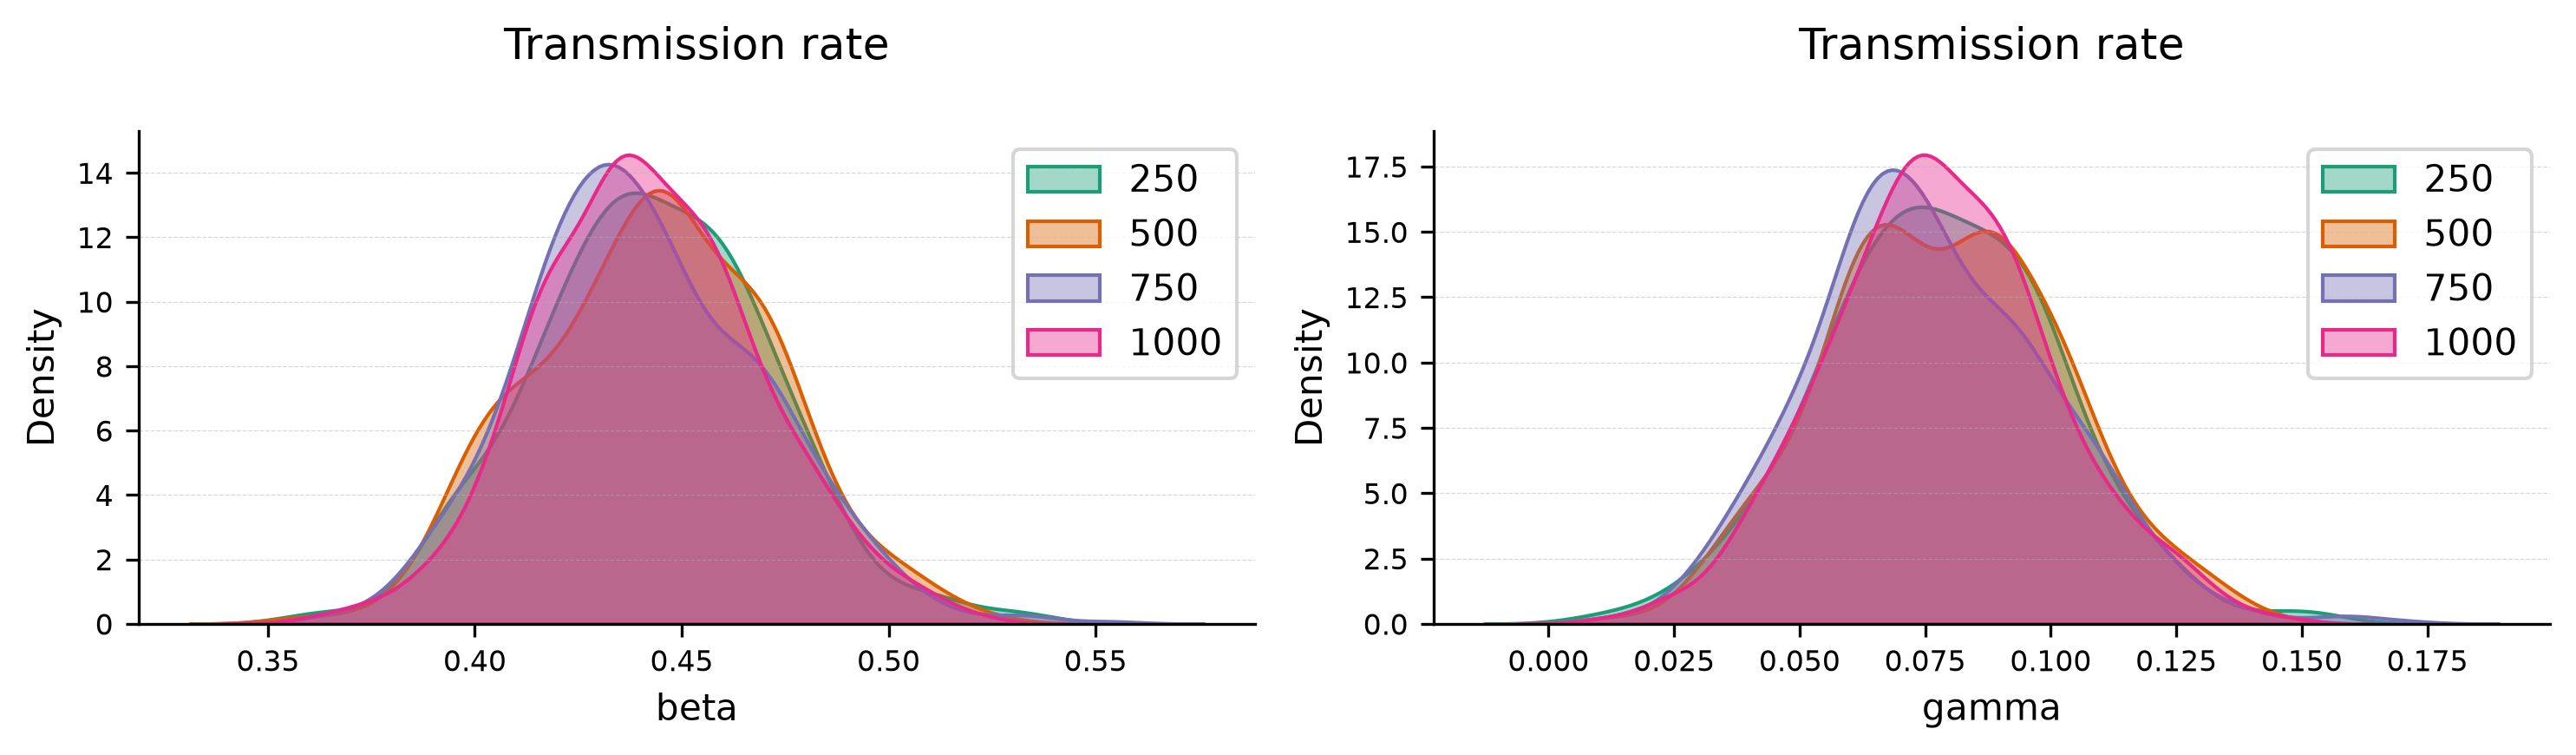

In [61]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), dpi=300)
plot_posterior_distribution(results_250.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[0], title="Transmission rate", prior_range=False, label="250")
plot_posterior_distribution(results_500.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[1], title="Transmission rate", prior_range=False, label="500")
plot_posterior_distribution(results_750.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[2], title="Transmission rate", prior_range=False, label="750")
plot_posterior_distribution(results_1000.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[3], title="Transmission rate", prior_range=False, label="1000")
axes[0].legend()    

plot_posterior_distribution(results_250.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[0], title="Transmission rate", prior_range=False, label="250")
plot_posterior_distribution(results_500.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[1], title="Transmission rate", prior_range=False, label="500")
plot_posterior_distribution(results_750.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[2], title="Transmission rate", prior_range=False, label="750")
plot_posterior_distribution(results_1000.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[3], title="Transmission rate", prior_range=False, label="1000")
axes[1].legend()

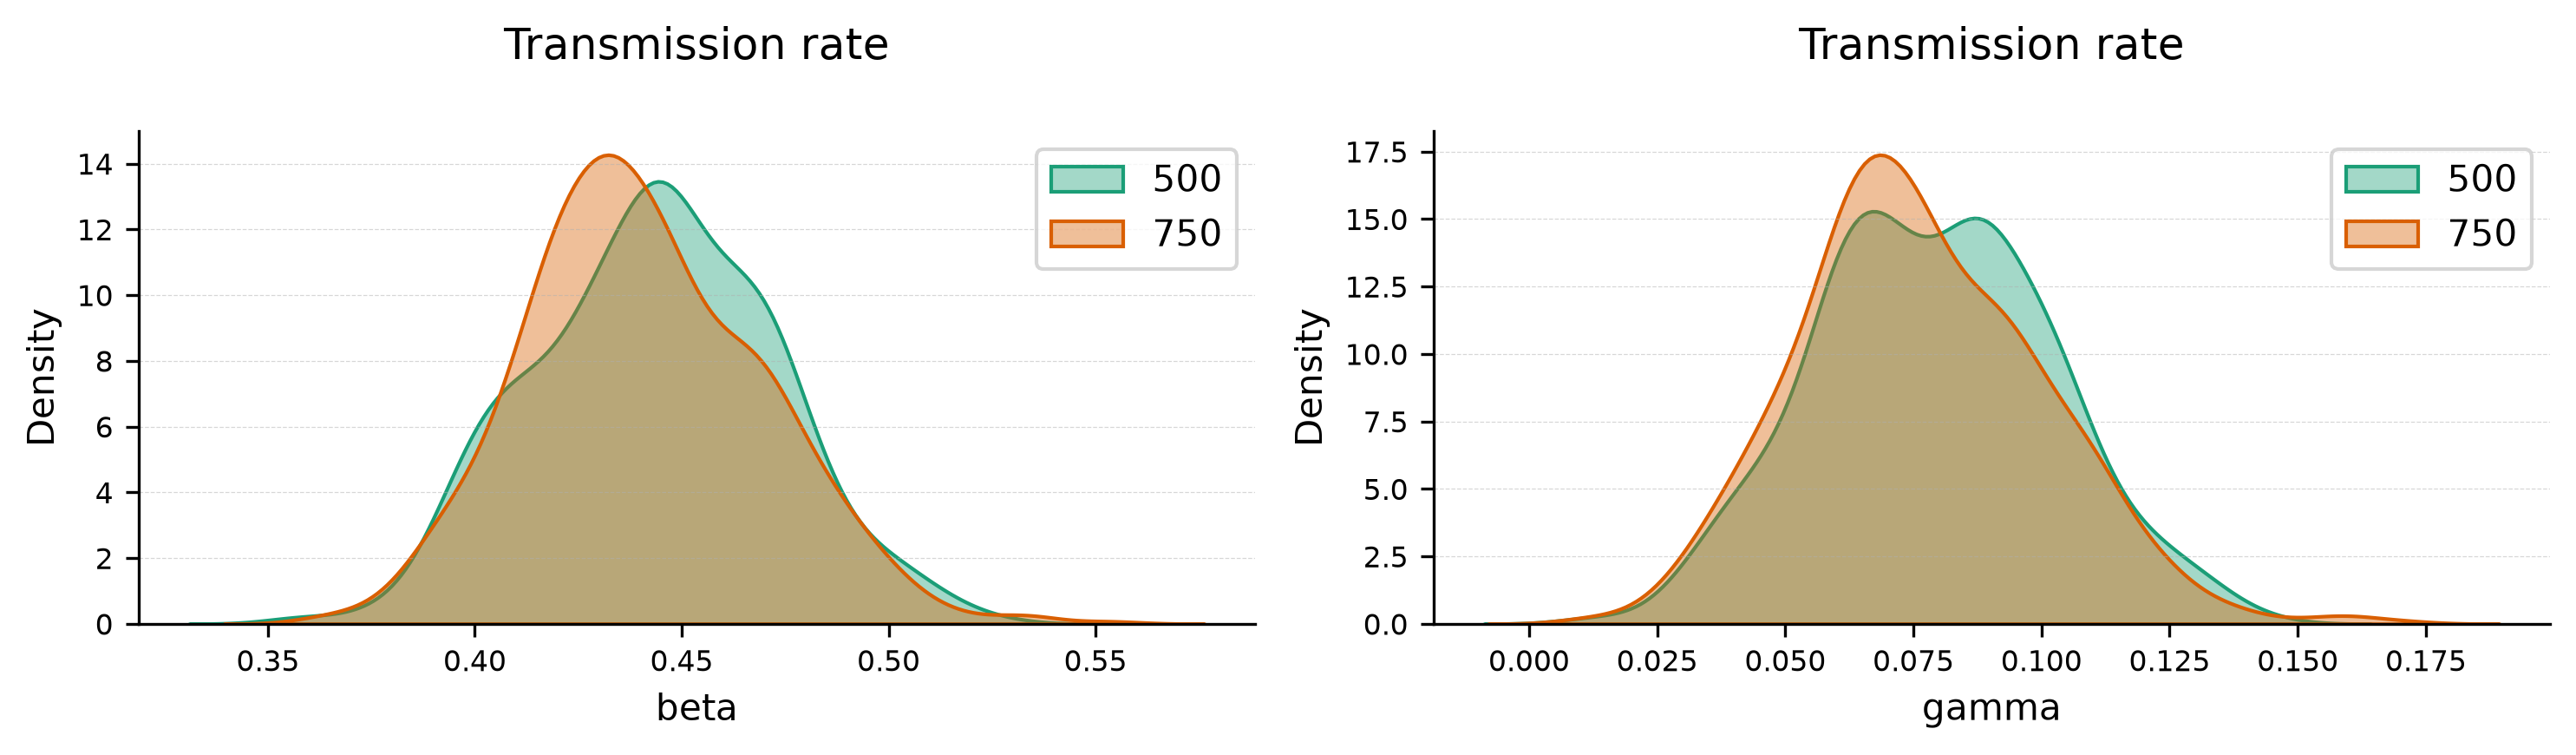

In [62]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), dpi=300)
plot_posterior_distribution(results_500.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[0], title="Transmission rate", prior_range=False, label="500")
plot_posterior_distribution(results_750.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[1], title="Transmission rate", prior_range=False, label="750")
#plot_posterior_distribution(results_1000.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[2], title="Transmission rate", prior_range=False, label="1000")
axes[0].legend()    

plot_posterior_distribution(results_500.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[0], title="Transmission rate", prior_range=False, label="500")
plot_posterior_distribution(results_750.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[1], title="Transmission rate", prior_range=False, label="750")
#plot_posterior_distribution(results_1000.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[2], title="Transmission rate", prior_range=False, label="1000")
axes[1].legend()

### ESS

In [63]:
def weighted_ess_test(generation, smc):
    weights = smc.weights[generation]
    w = weights / np.sum(weights)
    ess = 1 / np.sum(w**2)
    return ess

In [64]:
print(f'250')
for i in range(10):
    ess = weighted_ess_test(i, results_250)
    print(f"The ESS {i} particles is: {ess:.2f}")

250
The ESS 0 particles is: 250.00
The ESS 1 particles is: 174.43
The ESS 2 particles is: 154.34
The ESS 3 particles is: 138.13
The ESS 4 particles is: 163.28
The ESS 5 particles is: 190.49
The ESS 6 particles is: 208.99
The ESS 7 particles is: 225.34
The ESS 8 particles is: 228.63
The ESS 9 particles is: 239.88


In [65]:
print(f'500')
for i in range(10):
    ess = weighted_ess_test(i, results_500)
    print(f"The ESS {i} particles is: {ess:.2f}")

500
The ESS 0 particles is: 500.00
The ESS 1 particles is: 400.45
The ESS 2 particles is: 325.76
The ESS 3 particles is: 309.01
The ESS 4 particles is: 341.89
The ESS 5 particles is: 386.76
The ESS 6 particles is: 424.91
The ESS 7 particles is: 444.75
The ESS 8 particles is: 473.27
The ESS 9 particles is: 478.64


In [66]:
print(f'750')
for i in range(10):
    ess = weighted_ess_test(i, results_750)
    print(f"The ESS {i} particles is: {ess:.2f}")

750
The ESS 0 particles is: 750.00
The ESS 1 particles is: 545.17
The ESS 2 particles is: 452.46
The ESS 3 particles is: 445.44
The ESS 4 particles is: 473.38
The ESS 5 particles is: 548.47
The ESS 6 particles is: 623.31
The ESS 7 particles is: 677.92
The ESS 8 particles is: 702.29
The ESS 9 particles is: 719.13


In [67]:
print(f'1000')
for i in range(10):
    ess = weighted_ess_test(i, results_1000)
    print(f"The ESS {i} particles is: {ess:.2f}")

1000
The ESS 0 particles is: 1000.00
The ESS 1 particles is: 762.83
The ESS 2 particles is: 624.26
The ESS 3 particles is: 582.42
The ESS 4 particles is: 642.00
The ESS 5 particles is: 736.91
The ESS 6 particles is: 812.60
The ESS 7 particles is: 874.82
The ESS 8 particles is: 924.49
The ESS 9 particles is: 964.17


# Number of Generations

## Calibration

In [86]:
def smc_calibrate_gen(seed, generations):
    np.random.seed(seed)
    results_smc = abc_sampler.calibrate(strategy='smc',
                                    num_particles=1000,
                                    num_generations=generations,
                                    )
    return results_smc

In [87]:
results_5 = smc_calibrate_gen(1, 5)

Starting ABC-SMC with 1000 particles and 5 generations

Generation 1/5 (epsilon: inf)
	Accepted 1000/1000 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/5 (epsilon: 215.114786)
	Accepted 1000/3893 (acceptance rate: 25.69%)
	Elapsed time: 00:00:02

Generation 3/5 (epsilon: 124.942715)
	Accepted 1000/6615 (acceptance rate: 15.12%)
	Elapsed time: 00:00:02

Generation 4/5 (epsilon: 64.642979)
	Accepted 1000/10261 (acceptance rate: 9.75%)
	Elapsed time: 00:00:02

Generation 5/5 (epsilon: 37.493864)
	Accepted 1000/16929 (acceptance rate: 5.91%)
	Elapsed time: 00:00:03


In [88]:
results_7 = smc_calibrate_gen(1, 7)

Starting ABC-SMC with 1000 particles and 7 generations

Generation 1/7 (epsilon: inf)
	Accepted 1000/1000 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/7 (epsilon: 204.177685)
	Accepted 1000/3789 (acceptance rate: 26.39%)
	Elapsed time: 00:00:02

Generation 3/7 (epsilon: 112.814255)
	Accepted 1000/6782 (acceptance rate: 14.74%)
	Elapsed time: 00:00:02

Generation 4/7 (epsilon: 58.800815)
	Accepted 1000/11068 (acceptance rate: 9.04%)
	Elapsed time: 00:00:03

Generation 5/7 (epsilon: 34.786009)
	Accepted 1000/18422 (acceptance rate: 5.43%)
	Elapsed time: 00:00:03

Generation 6/7 (epsilon: 23.956311)
	Accepted 1000/31313 (acceptance rate: 3.19%)
	Elapsed time: 00:00:05

Generation 7/7 (epsilon: 18.074420)
	Accepted 1000/52098 (acceptance rate: 1.92%)
	Elapsed time: 00:00:06


In [89]:
results_10 = smc_calibrate_gen(1, 10)

Starting ABC-SMC with 1000 particles and 10 generations

Generation 1/10 (epsilon: inf)
	Accepted 1000/1000 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/10 (epsilon: 199.130427)
	Accepted 1000/3948 (acceptance rate: 25.33%)
	Elapsed time: 00:00:02

Generation 3/10 (epsilon: 112.763101)
	Accepted 1000/6714 (acceptance rate: 14.89%)
	Elapsed time: 00:00:02

Generation 4/10 (epsilon: 61.072573)
	Accepted 1000/10856 (acceptance rate: 9.21%)
	Elapsed time: 00:00:02

Generation 5/10 (epsilon: 34.844655)
	Accepted 1000/18522 (acceptance rate: 5.40%)
	Elapsed time: 00:00:03

Generation 6/10 (epsilon: 23.475062)
	Accepted 1000/31677 (acceptance rate: 3.16%)
	Elapsed time: 00:00:05

Generation 7/10 (epsilon: 17.878339)
	Accepted 1000/55149 (acceptance rate: 1.81%)
	Elapsed time: 00:00:07

Generation 8/10 (epsilon: 14.805911)
	Accepted 1000/94496 (acceptance rate: 1.06%)
	Elapsed time: 00:00:10

Generation 9/10 (epsilon: 12.936576)
	Accepted 1000/163125 (acceptance rate: 0.61%

In [90]:
results_15 = smc_calibrate_gen(1, 15)

Starting ABC-SMC with 1000 particles and 15 generations

Generation 1/15 (epsilon: inf)
	Accepted 1000/1000 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/15 (epsilon: 198.146546)
	Accepted 1000/4015 (acceptance rate: 24.91%)
	Elapsed time: 00:00:02

Generation 3/15 (epsilon: 99.788852)
	Accepted 1000/7237 (acceptance rate: 13.82%)
	Elapsed time: 00:00:02

Generation 4/15 (epsilon: 50.844960)
	Accepted 1000/11944 (acceptance rate: 8.37%)
	Elapsed time: 00:00:03

Generation 5/15 (epsilon: 31.878597)
	Accepted 1000/19861 (acceptance rate: 5.03%)
	Elapsed time: 00:00:03

Generation 6/15 (epsilon: 22.070908)
	Accepted 1000/34932 (acceptance rate: 2.86%)
	Elapsed time: 00:00:05

Generation 7/15 (epsilon: 17.307495)
	Accepted 1000/59231 (acceptance rate: 1.69%)
	Elapsed time: 00:00:07

Generation 8/15 (epsilon: 14.426018)
	Accepted 1000/101859 (acceptance rate: 0.98%)
	Elapsed time: 00:00:11

Generation 9/15 (epsilon: 12.664715)
	Accepted 1000/172805 (acceptance rate: 0.58%

## Posterior Analysis

In [91]:
posterior_5 = results_5.get_posterior_distribution()
posterior_7 = results_7.get_posterior_distribution()
posterior_10 = results_10.get_posterior_distribution()
posterior_15 = results_15.get_posterior_distribution()

In [92]:
beta_mean_5 = np.mean(posterior_5['beta'])
beta_mean_7 = np.mean(posterior_7['beta'])
beta_mean_10 = np.mean(posterior_10['beta'])
beta_mean_15 = np.mean(posterior_15['beta'])

gamma_mean_5 = np.mean(posterior_5['gamma'])
gamma_mean_7 = np.mean(posterior_7['gamma'])
gamma_mean_10 = np.mean(posterior_10['gamma'])
gamma_mean_15 = np.mean(posterior_15['gamma'])


beta_true=0.45
summary_beta = {'Number of Generations': ['5', '7', '10', '15'],
           'Mean': [beta_mean_5, beta_mean_7, beta_mean_10, beta_mean_15],
           'Bias': [(beta_mean_5 - beta_true), (beta_mean_7 - beta_true), (beta_mean_10 - beta_true), (beta_mean_15 - beta_true)]}

gamma_true=0.08
summary_gamma = {'Number of Generations': ['5', '7', '10', '15'],
           'Mean': [gamma_mean_5, gamma_mean_7, gamma_mean_10, gamma_mean_15],
           'Bias': [(gamma_mean_5 - gamma_true), (gamma_mean_7 - gamma_true), (gamma_mean_10 - gamma_true), (gamma_mean_15 - gamma_true)]}


df_summary_beta = pd.DataFrame(summary_beta)
df_summary_gamma = pd.DataFrame(summary_gamma)

display(df_summary_beta)
display(df_summary_gamma)

,Number of Generations,Mean,Bias
0,5,0.455509,0.005509
1,7,0.447207,-0.002793
2,10,0.439654,-0.010346
3,15,0.439411,-0.010589


,Number of Generations,Mean,Bias
0,5,0.090492,0.010492
1,7,0.081721,0.001721
2,10,0.075387,-0.004613
3,15,0.074941,-0.005059


### Posterior Distribution Plots

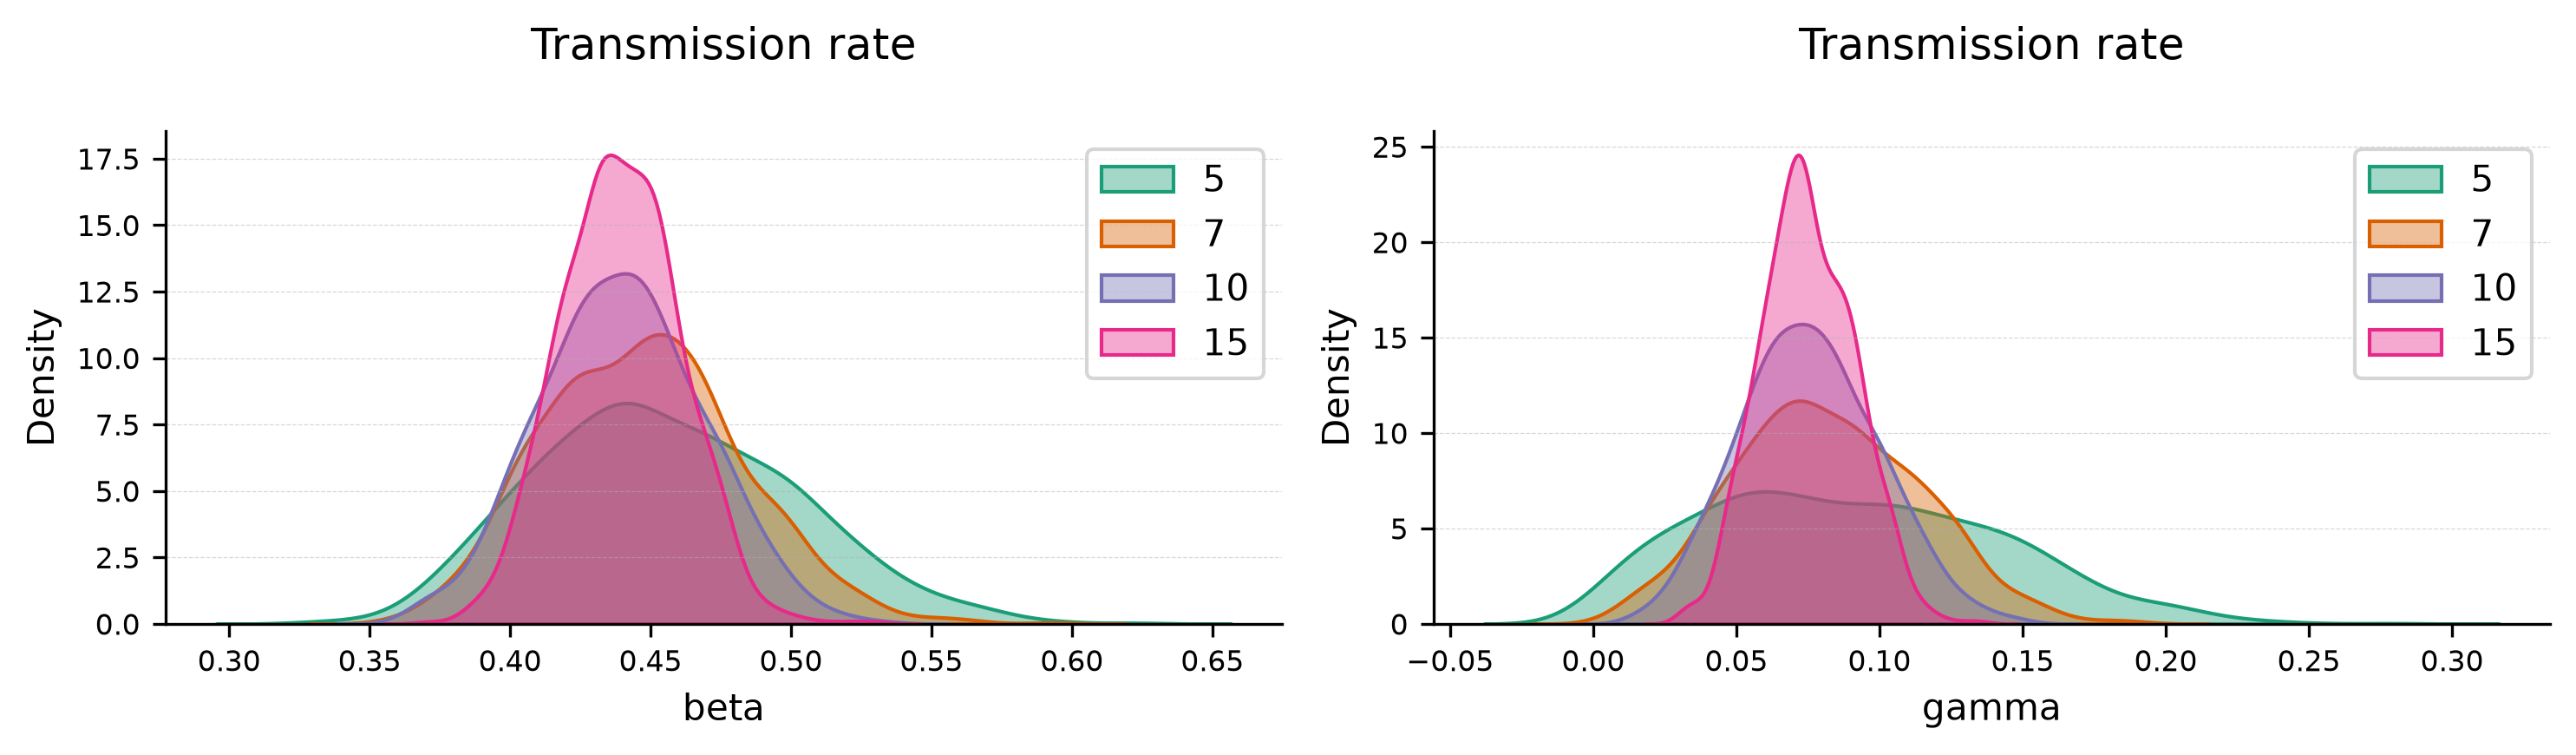

In [93]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), dpi=300)
plot_posterior_distribution(results_5.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[0], title="Transmission rate", prior_range=False, label="5")
plot_posterior_distribution(results_7.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[1], title="Transmission rate", prior_range=False, label="7")
plot_posterior_distribution(results_10.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[2], title="Transmission rate", prior_range=False, label="10")
plot_posterior_distribution(results_15.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[3], title="Transmission rate", prior_range=False, label="15")
axes[0].legend()    

plot_posterior_distribution(results_5.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[0], title="Transmission rate", prior_range=False, label="5")
plot_posterior_distribution(results_7.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[1], title="Transmission rate", prior_range=False, label="7")
plot_posterior_distribution(results_10.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[2], title="Transmission rate", prior_range=False, label="10")
plot_posterior_distribution(results_15.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[3], title="Transmission rate", prior_range=False, label="15")
axes[1].legend()

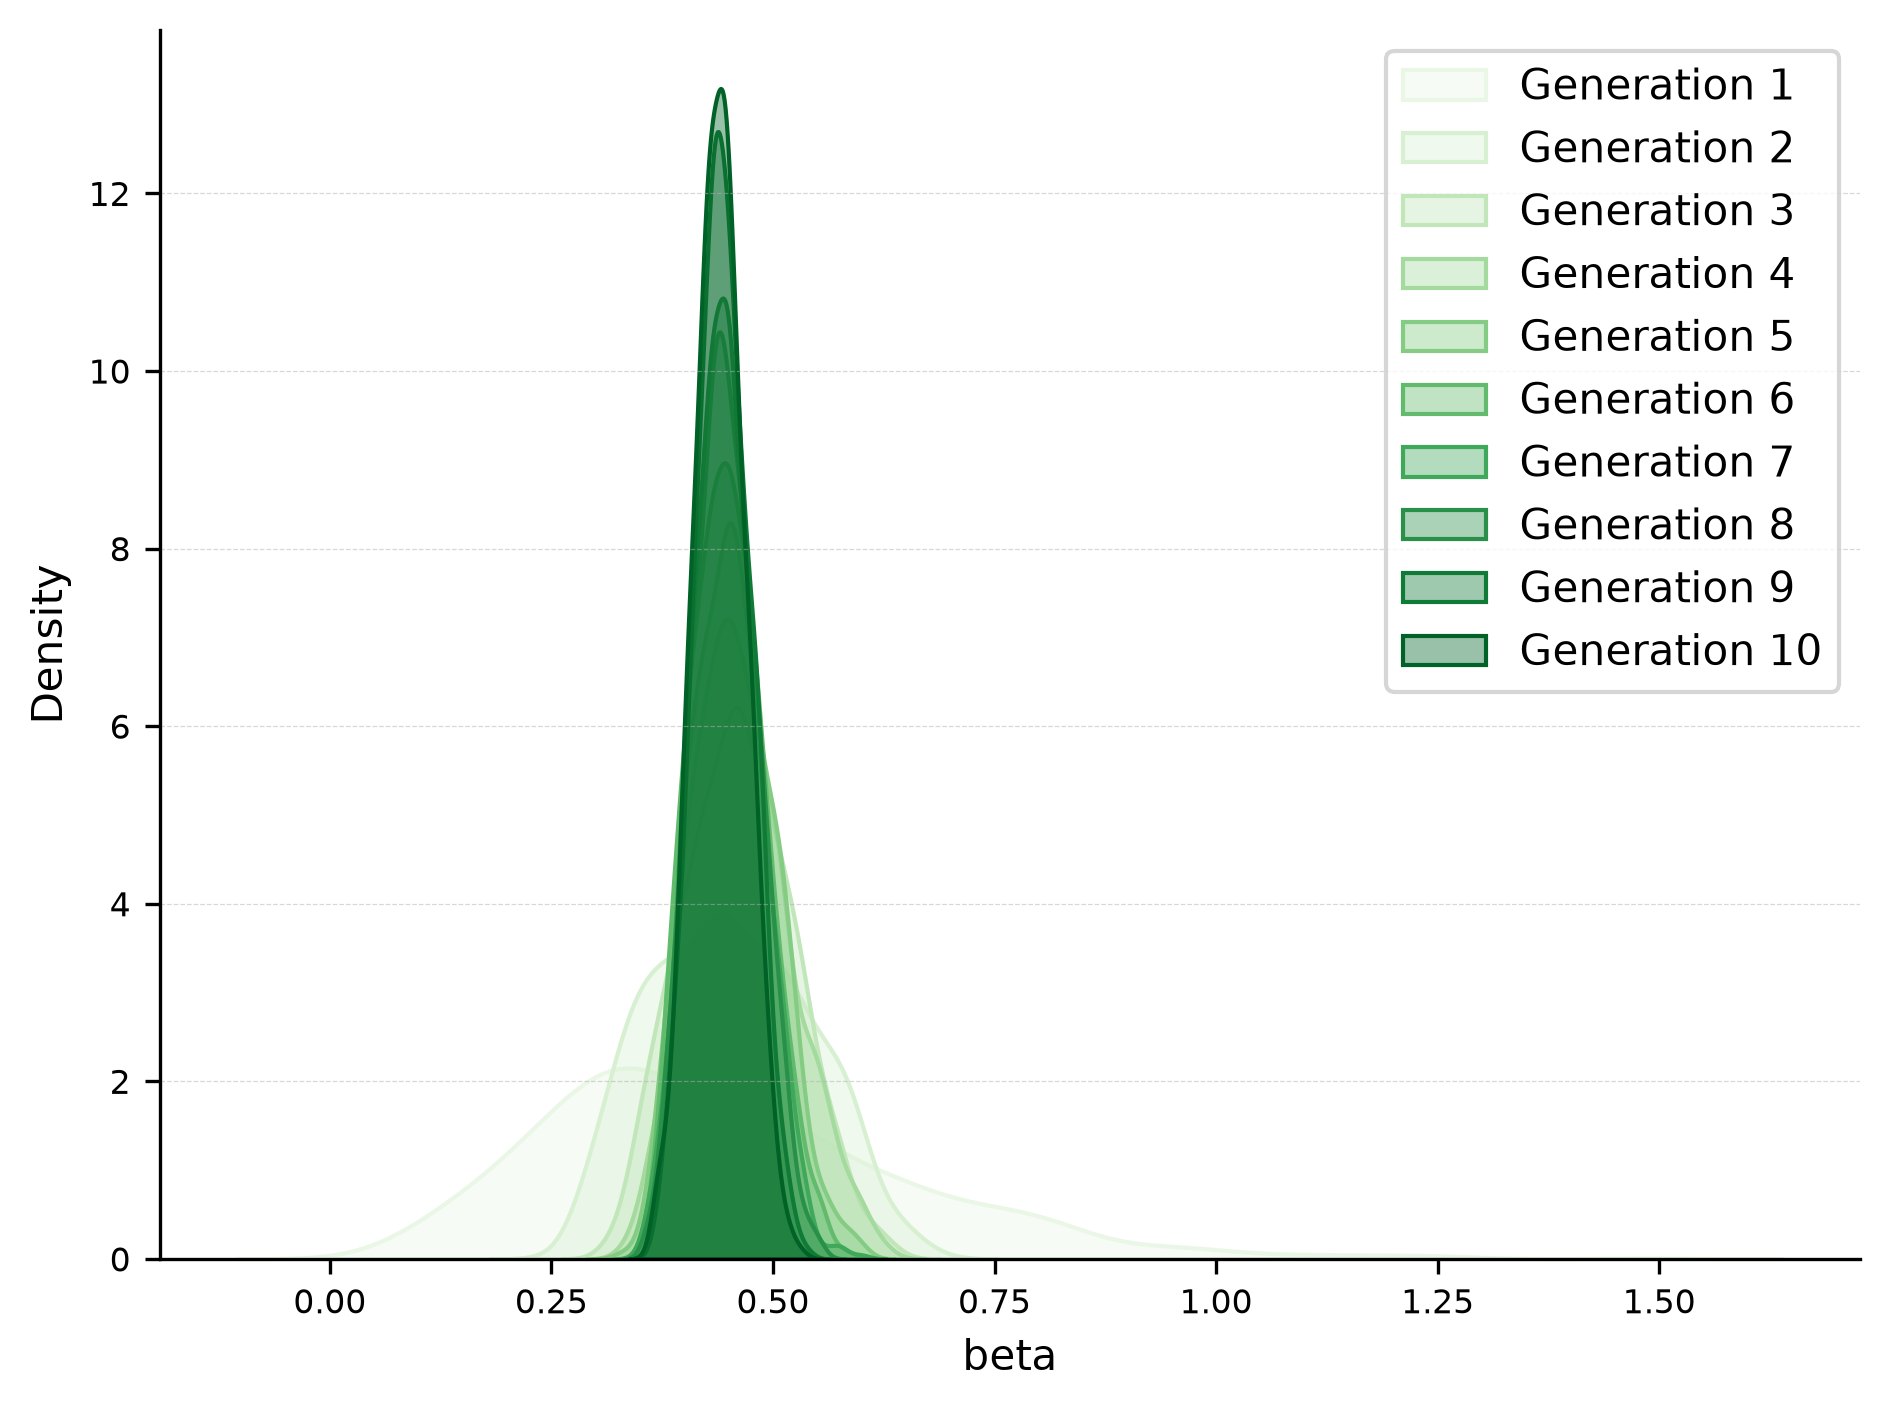

In [94]:
# Distance distributions over 10 generations
fig, ax = plt.subplots(dpi=300)
for generation, color in zip(range(10), sns.color_palette("Greens", n_colors=10)): 
    plot_posterior_distribution(results_10.get_posterior_distribution(generation=generation), 
                                parameter="beta", ax=ax, kind="kde", color=color, label="Generation %d" % (generation+1))
ax.legend() 

### ESS

In [95]:
print(f'5')
for i in range(5):
    ess = weighted_ess_test(i, results_5)
    print(f"The ESS {i} particles is: {ess:.2f}")

5
The ESS 0 particles is: 1000.00
The ESS 1 particles is: 734.12
The ESS 2 particles is: 608.01
The ESS 3 particles is: 560.21
The ESS 4 particles is: 622.66


In [96]:
print(f'7')
for i in range(7):
    ess = weighted_ess_test(i, results_7)
    print(f"The ESS {i} particles is: {ess:.2f}")

7
The ESS 0 particles is: 1000.00
The ESS 1 particles is: 717.77
The ESS 2 particles is: 604.29
The ESS 3 particles is: 568.35
The ESS 4 particles is: 632.82
The ESS 5 particles is: 756.67
The ESS 6 particles is: 845.51


In [97]:
print(f'10')
for i in range(10):
    ess = weighted_ess_test(i, results_10)
    print(f"The ESS {i} particles is: {ess:.2f}")

10
The ESS 0 particles is: 1000.00
The ESS 1 particles is: 762.03
The ESS 2 particles is: 590.38
The ESS 3 particles is: 551.36
The ESS 4 particles is: 646.36
The ESS 5 particles is: 736.89
The ESS 6 particles is: 835.78
The ESS 7 particles is: 888.16
The ESS 8 particles is: 926.22
The ESS 9 particles is: 954.00


In [98]:
print(f'15')
for i in range(15):
    ess = weighted_ess_test(i, results_15)
    print(f"The ESS {i} particles is: {ess:.2f}")

15
The ESS 0 particles is: 1000.00
The ESS 1 particles is: 748.06
The ESS 2 particles is: 622.41
The ESS 3 particles is: 607.05
The ESS 4 particles is: 676.88
The ESS 5 particles is: 752.02
The ESS 6 particles is: 832.13
The ESS 7 particles is: 888.83
The ESS 8 particles is: 941.68
The ESS 9 particles is: 966.76
The ESS 10 particles is: 973.81
The ESS 11 particles is: 979.06
The ESS 12 particles is: 985.42
The ESS 13 particles is: 990.49
The ESS 14 particles is: 981.09


### 10 Generation Run: Posterior mean estimates for last 5 generations

In [99]:
posterior_10_5 = results_10.get_posterior_distribution(generation=5)
posterior_10_6 = results_10.get_posterior_distribution(generation=6)
posterior_10_7 = results_10.get_posterior_distribution(generation=7)
posterior_10_8 = results_10.get_posterior_distribution(generation=8)
posterior_10_9 = results_10.get_posterior_distribution(generation=9)


In [100]:
beta_mean_15_10 = np.mean(posterior_10_5['beta'])
beta_mean_15_11 = np.mean(posterior_10_6['beta'])
beta_mean_15_12 = np.mean(posterior_10_7['beta'])
beta_mean_15_13 = np.mean(posterior_10_8['beta'])
beta_mean_15_14 = np.mean(posterior_10_9['beta'])

gamma_mean_15_10 = np.mean(posterior_10_5['gamma'])
gamma_mean_15_11 = np.mean(posterior_10_6['gamma'])
gamma_mean_15_12 = np.mean(posterior_10_7['gamma'])
gamma_mean_15_13 = np.mean(posterior_10_8['gamma'])
gamma_mean_15_14 = np.mean(posterior_10_9['gamma'])


beta_true=0.3
summary_beta = {'Generation': ['5', '6', '7', '8', '9'],
           'Mean': [beta_mean_15_10, beta_mean_15_11, beta_mean_15_12, beta_mean_15_13, beta_mean_15_14],
           'Bias': [(beta_mean_15_10 - beta_true), (beta_mean_15_11 - beta_true), (beta_mean_15_12 - beta_true), (beta_mean_15_13 - beta_true), (beta_mean_15_14 - beta_true)]}

gamma_true=0.1
summary_gamma = {'Generation': ['5', '6', '7', '7', '8'],
           'Mean': [gamma_mean_15_10, gamma_mean_15_11, gamma_mean_15_12, gamma_mean_15_13, gamma_mean_15_14],
           'Bias': [(gamma_mean_15_10 - gamma_true), (gamma_mean_15_11 - gamma_true), (gamma_mean_15_12 - gamma_true), (gamma_mean_15_13 - gamma_true), (gamma_mean_15_14 - gamma_true)]}


df_summary_beta = pd.DataFrame(summary_beta)
df_summary_gamma = pd.DataFrame(summary_gamma)

display(df_summary_beta)
display(df_summary_gamma)

,Generation,Mean,Bias
0,5,0.448689,0.148689
1,6,0.447044,0.147044
2,7,0.445876,0.145876
3,8,0.443651,0.143651
4,9,0.439654,0.139654


,Generation,Mean,Bias
0,5,0.083499,-0.016501
1,6,0.081979,-0.018021
2,7,0.080998,-0.019002
3,7,0.078942,-0.021058
4,8,0.075387,-0.024613


## 9 Generations

In [101]:
results_9 = smc_calibrate_gen(1, 9)

Starting ABC-SMC with 1000 particles and 9 generations

Generation 1/9 (epsilon: inf)
	Accepted 1000/1000 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/9 (epsilon: 201.952536)
	Accepted 1000/3890 (acceptance rate: 25.71%)
	Elapsed time: 00:00:02

Generation 3/9 (epsilon: 112.953398)
	Accepted 1000/6816 (acceptance rate: 14.67%)
	Elapsed time: 00:00:02

Generation 4/9 (epsilon: 60.378512)
	Accepted 1000/10893 (acceptance rate: 9.18%)
	Elapsed time: 00:00:03

Generation 5/9 (epsilon: 35.548835)
	Accepted 1000/17095 (acceptance rate: 5.85%)
	Elapsed time: 00:00:03

Generation 6/9 (epsilon: 23.935329)
	Accepted 1000/29270 (acceptance rate: 3.42%)
	Elapsed time: 00:00:04

Generation 7/9 (epsilon: 17.820915)
	Accepted 1000/52104 (acceptance rate: 1.92%)
	Elapsed time: 00:00:07

Generation 8/9 (epsilon: 14.744660)
	Accepted 1000/87735 (acceptance rate: 1.14%)
	Elapsed time: 00:00:10

Generation 9/9 (epsilon: 12.877694)
	Accepted 1000/156638 (acceptance rate: 0.64%)
	Elapsed

In [102]:
posterior_9 = results_9.get_posterior_distribution()

beta_mean_9 = np.mean(posterior_9['beta'])
gamma_mean_9 = np.mean(posterior_9['gamma'])

print(beta_mean_9, gamma_mean_9)

0.4424807043956895 0.07809094047236162


In [104]:
print(f'9')
for i in range(9):
    ess = weighted_ess_test(i, results_9)
    print(f"The ESS {i} particles is: {ess:.2f}")

9
The ESS 0 particles is: 1000.00
The ESS 1 particles is: 739.71
The ESS 2 particles is: 611.22
The ESS 3 particles is: 623.35
The ESS 4 particles is: 665.37
The ESS 5 particles is: 756.77
The ESS 6 particles is: 835.25
The ESS 7 particles is: 895.50
The ESS 8 particles is: 932.73


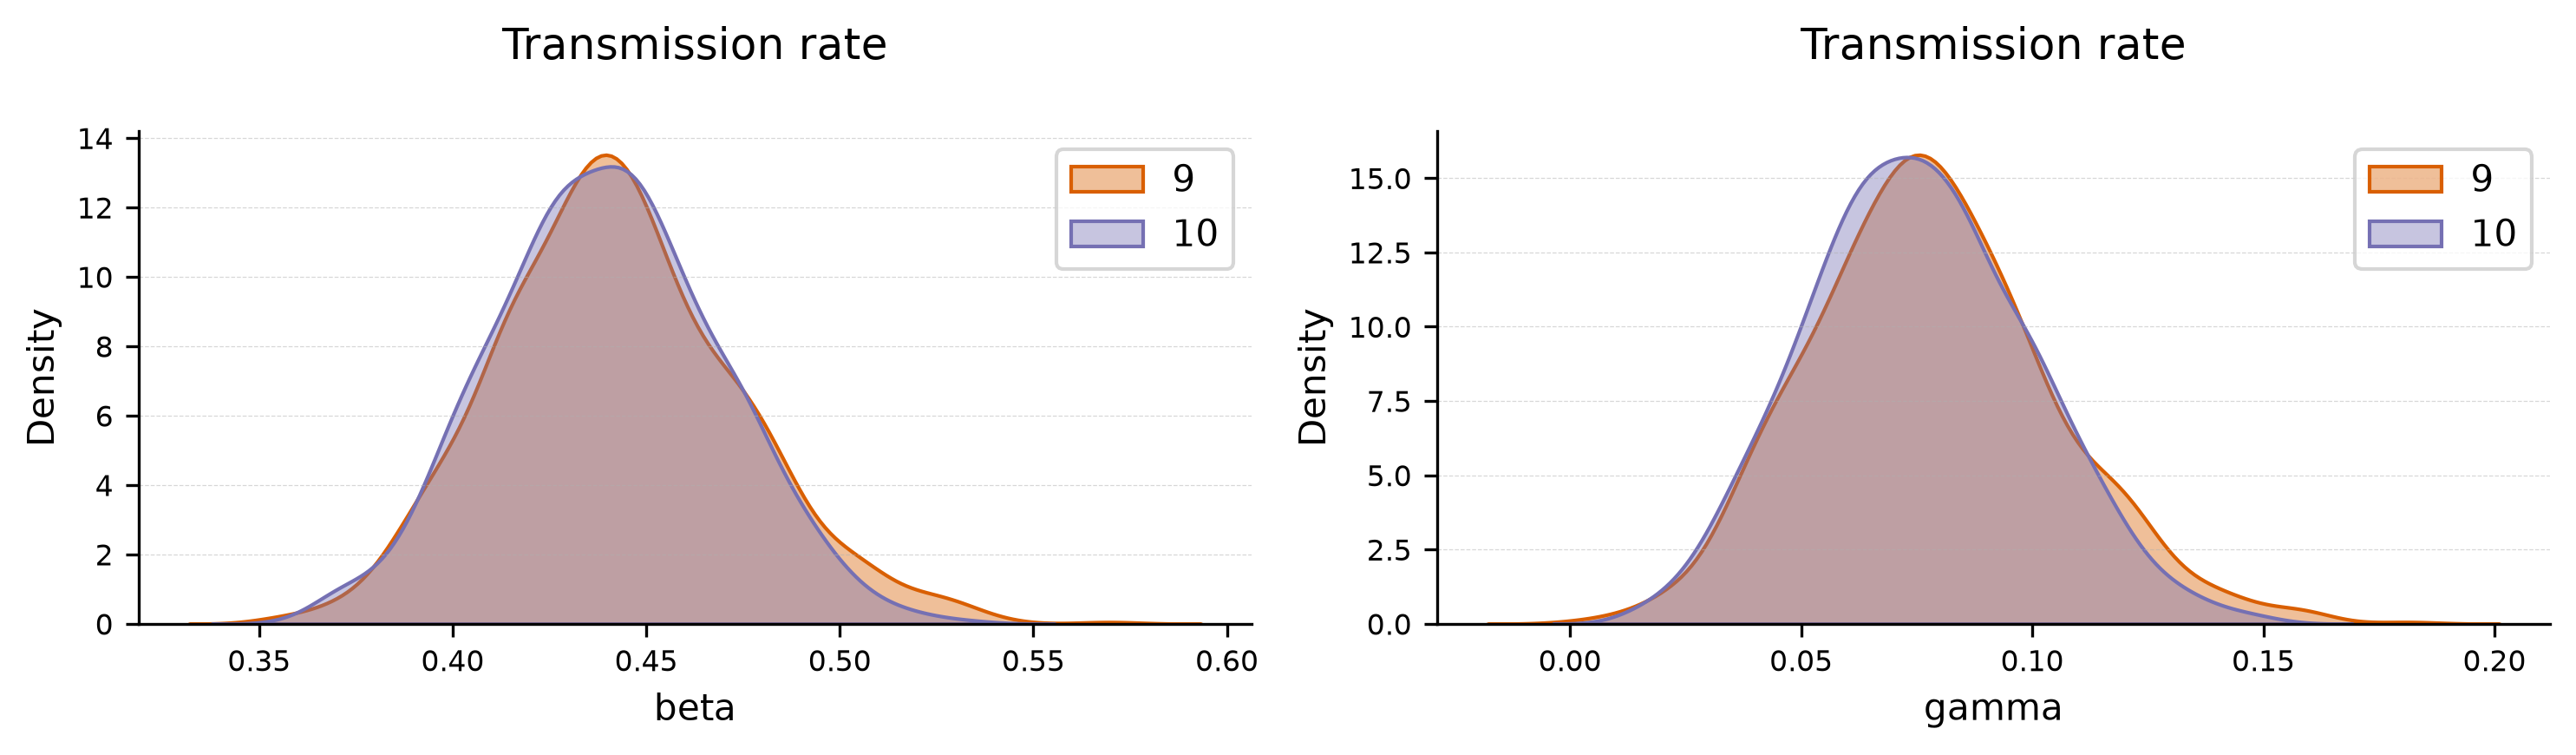

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), dpi=300)
plot_posterior_distribution(results_9.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[1], title="Transmission rate", prior_range=False, label="9")
plot_posterior_distribution(results_10.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", color=colors[2], title="Transmission rate", prior_range=False, label="10")
axes[0].legend()    

plot_posterior_distribution(results_9.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[1], title="Transmission rate", prior_range=False, label="9")
plot_posterior_distribution(results_10.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", color=colors[2], title="Transmission rate", prior_range=False, label="10")
axes[1].legend()

